In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)    # show all columns
pd.set_option('display.width', None)         # don't wrap columns
pd.set_option('display.width', 0)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('Airbnb_Open_Data.csv')

C:\Users\Babak\AppData\Local\Temp\ipykernel_8964\2167922700.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Airbnb_Open_Data.csv')


In [4]:
print(df.head())

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country country code instant_bookable  \
0  40.64749 -73.97237  United Stat

In [5]:
print(list(df))

['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


In [ ]:
## describe the dataframe
print(df.describe(include='number'))


                 id       host id            lat           long  \
count  1.025990e+05  1.025990e+05  102591.000000  102591.000000   
mean   2.914623e+07  4.925411e+10      40.728094     -73.949644   
std    1.625751e+07  2.853900e+10       0.055857       0.049521   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.508581e+07  2.458333e+10      40.688740     -73.982580   
50%    2.913660e+07  4.911774e+10      40.722290     -73.954440   
75%    4.320120e+07  7.399650e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   

       Construction year  minimum nights  number of reviews  \
count      102385.000000   102190.000000      102416.000000   
mean         2012.487464        8.135845          27.483743   
std             5.765556       30.553781          49.508954   
min          2003.000000    -1223.000000           0.000000   
25%          2007.000000        2.000000           1.000000   
50%          2012.

In [10]:
print(df.describe(include='object'))

                       NAME host_identity_verified host name  \
count                102349                 102310    102193   
unique                61281                      2     13190   
top     Home away from home            unconfirmed   Michael   
freq                     33                  51200       881   

       neighbourhood group       neighbourhood        country country code  \
count               102570              102583         102067       102468   
unique                   7                 224              1            1   
top              Manhattan  Bedford-Stuyvesant  United States           US   
freq                 43792                7937         102067       102468   

       instant_bookable cancellation_policy        room type   price  \
count            102494              102523           102599  102352   
unique                2                   3                4    1151   
top               False            moderate  Entire home/apt   $206    


## Data Preprocessing
- Removing nulls
- Parsing columns into right formats. e.g. time, price, etc.

In [ ]:
## missing values in each column
print('Missing values percentages')
print(f'{100 * df.isnull().mean().round(4)}%')

Missing values percentages
id                                  0.00
NAME                                0.24
host id                             0.00
host_identity_verified              0.28
host name                           0.40
neighbourhood group                 0.03
neighbourhood                       0.02
lat                                 0.01
long                                0.01
country                             0.52
country code                        0.13
instant_bookable                    0.10
cancellation_policy                 0.07
room type                           0.00
Construction year                   0.21
price                               0.24
service fee                         0.27
minimum nights                      0.40
number of reviews                   0.18
last review                        15.49
reviews per month                  15.48
review rate number                  0.32
calculated host listings count      0.31
availability 365              

In [25]:
cols = ['license', 'reviews per month', 'last review' , 'house_rules']

for c in cols:
    print(f"\n=== {c} ===")
    print(
        df[c].value_counts(normalize=True, dropna=False)
          .sort_values(ascending=False)
          .to_frame('pct')
    )


=== license ===
               pct
license           
NaN       0.999981
41662/AL  0.000019

=== reviews per month ===
                        pct
reviews per month          
NaN                0.154768
0.03               0.016238
0.05               0.014523
1.00               0.014181
0.04               0.012378
0.09               0.012369
0.08               0.012271
0.16               0.012261
0.06               0.011628
0.02               0.011345
0.11               0.011121
0.07               0.010575
0.13               0.010312
0.10               0.009620
0.12               0.009094
0.14               0.008879
0.15               0.008246
0.19               0.008119
0.21               0.007291
0.17               0.007291
0.18               0.007252
0.26               0.007213
0.22               0.007027
0.23               0.006881
0.24               0.006530
0.20               0.006472
0.25               0.006238
0.32               0.006179
0.27               0.006014
2.00        

### Does having house rules affect other data such as popularity, review and price?
 

In [18]:
## dealing with missing values  
df.drop(columns=['license'], inplace=True)

# 1. Numeric columns → median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 2. Categorical or ordinal columns → mode
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df[cat_cols] = df[cat_cols].apply(lambda col: col.fillna(col.mode()[0]))

C:\Users\Babak\AppData\Local\Temp\ipykernel_18624\367606150.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cat_cols] = df[cat_cols].apply(lambda col: col.fillna(col.mode()[0]))


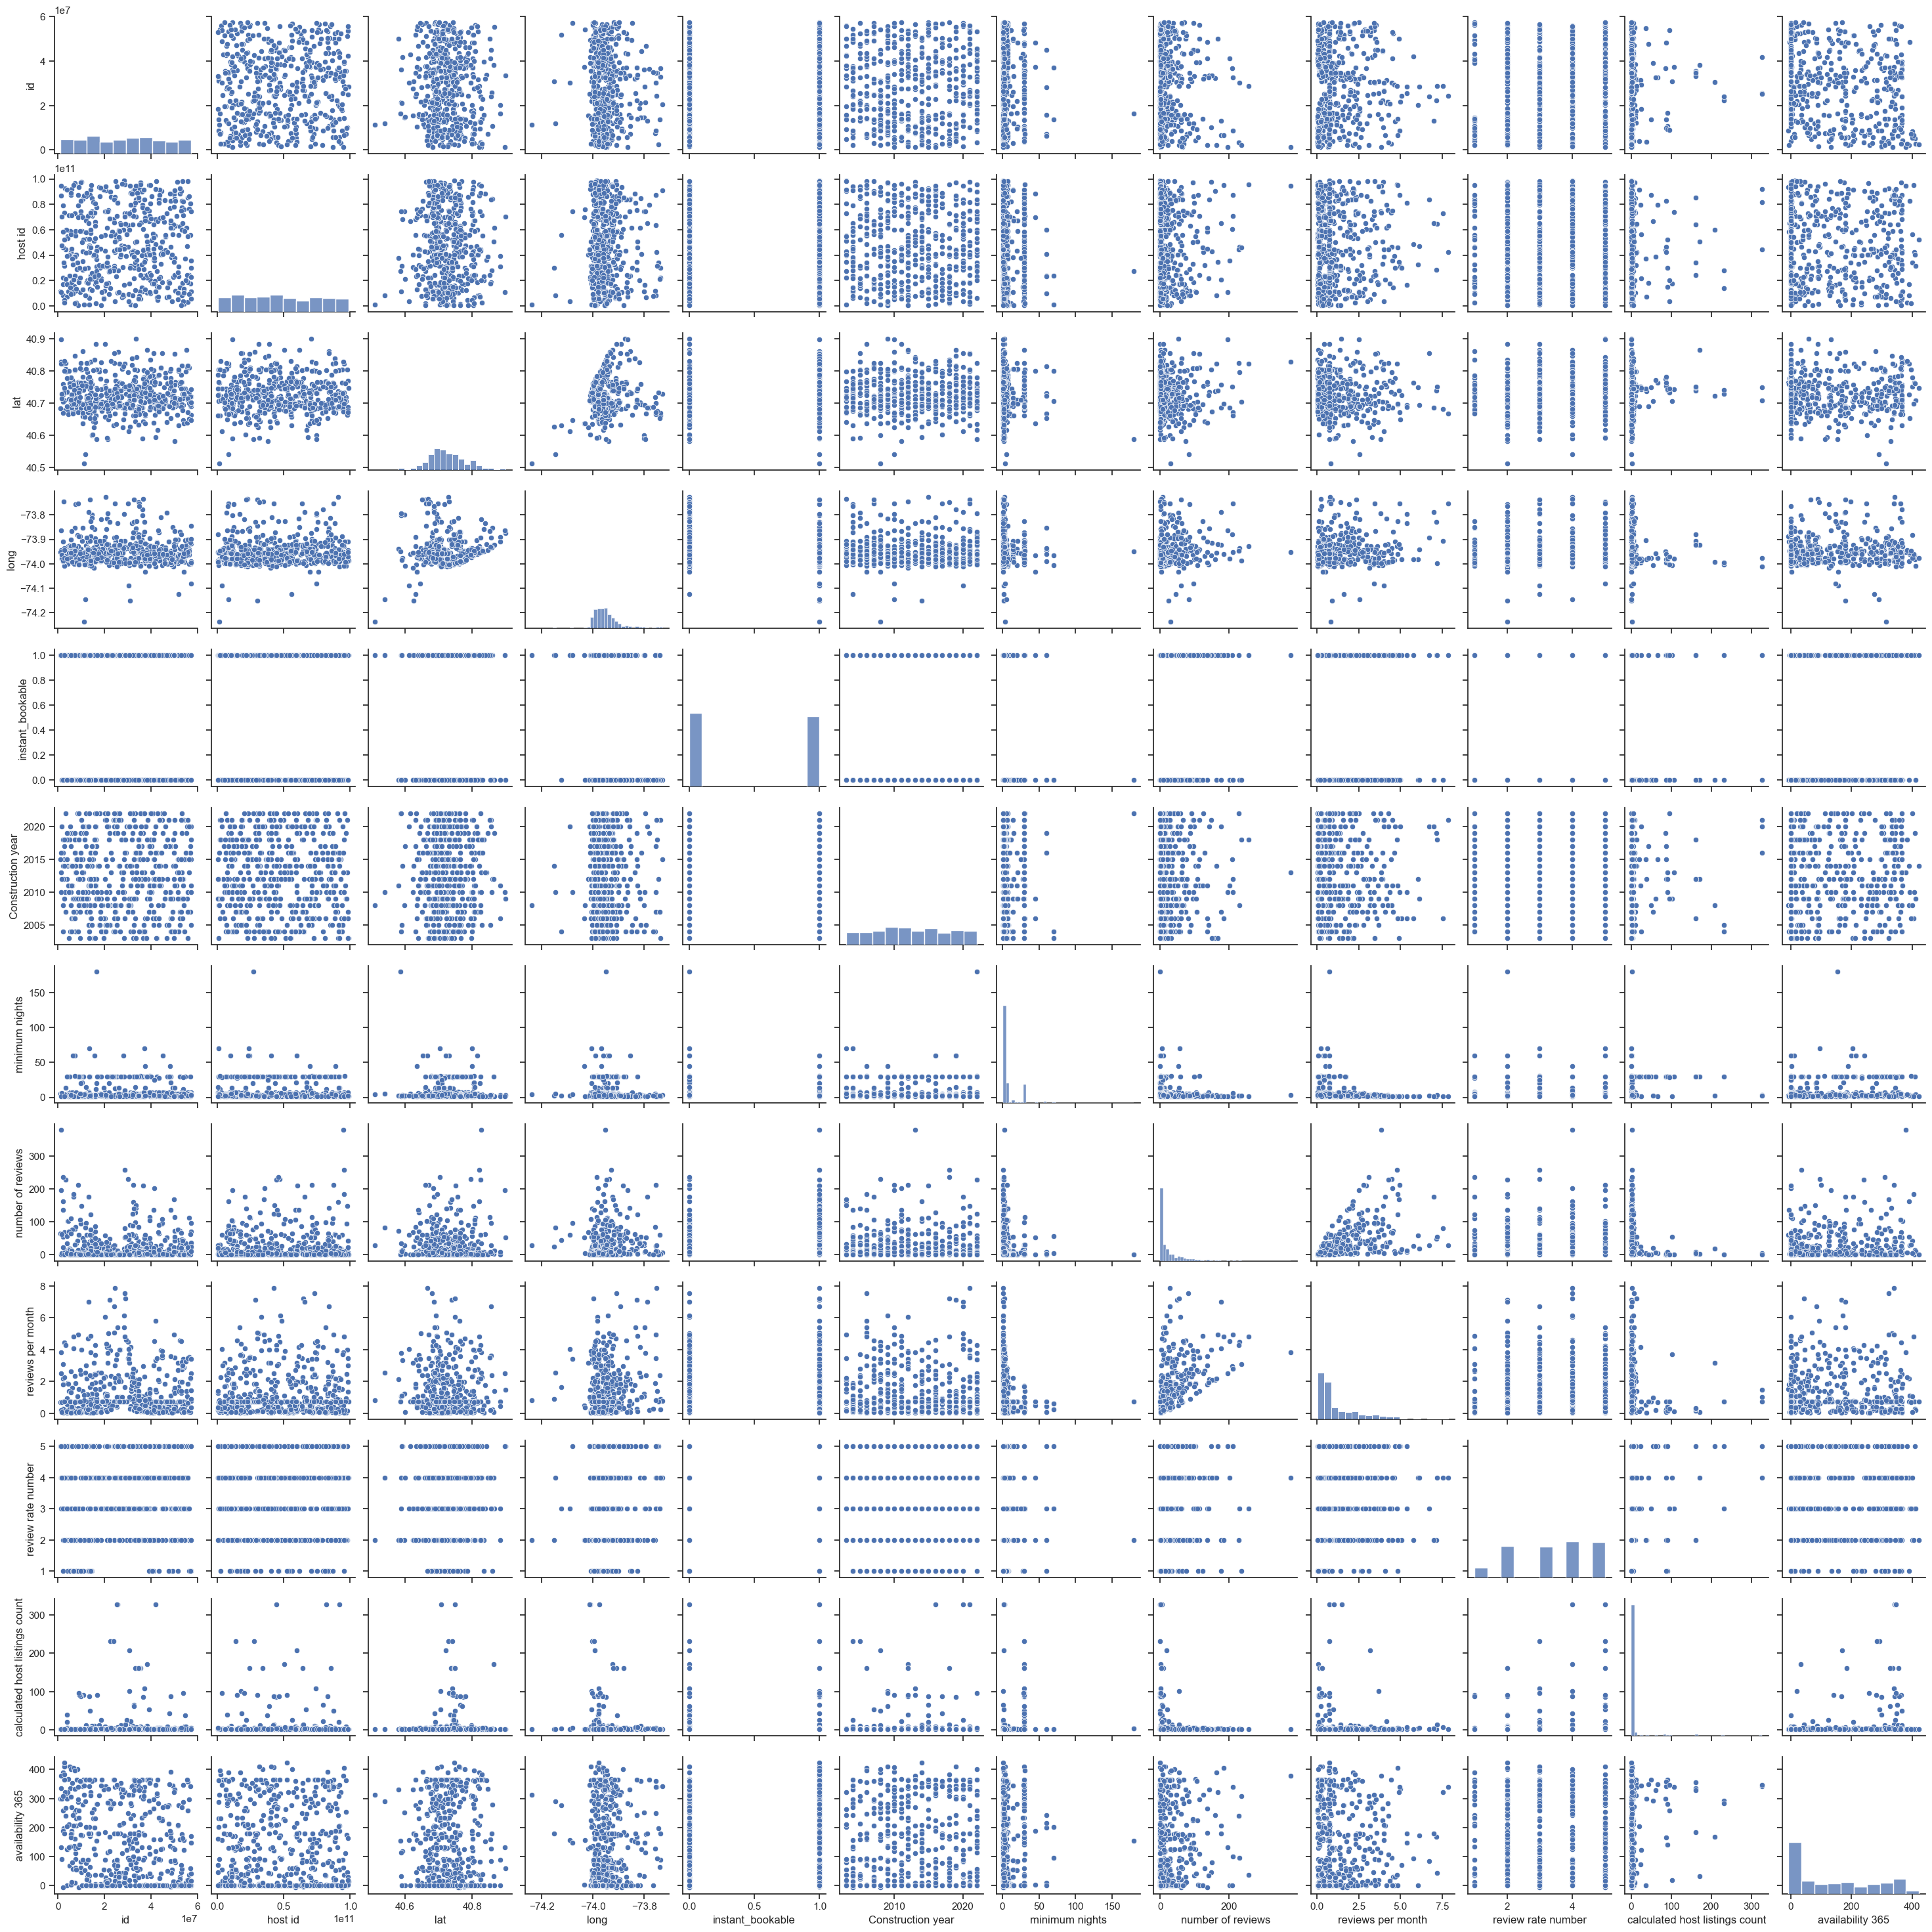

In [23]:
# pairplot
sns.set(style="ticks")
g = sns.pairplot(df.sample(500),
                 # hue="price"
                 )
g.fig.savefig("pairplot.png", dpi=300, bbox_inches="tight")

plt.show()

<Axes: xlabel='room type', ylabel='price'>

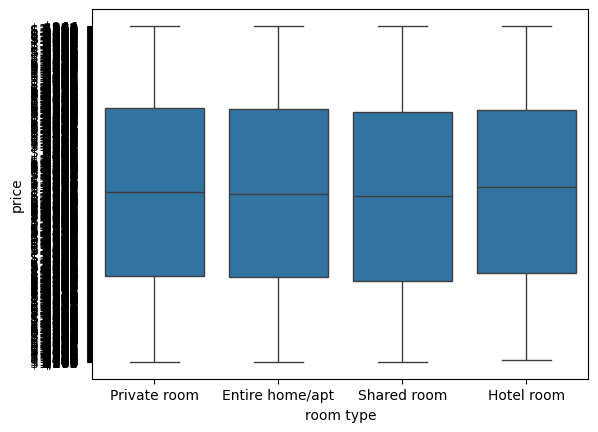

In [13]:
import seaborn as sns
# sns.histplot(df['price'], kde=True)  # numeric distribution
sns.boxplot(x='room type', y='price', data=df)  # compare numeric by category

<Axes: >

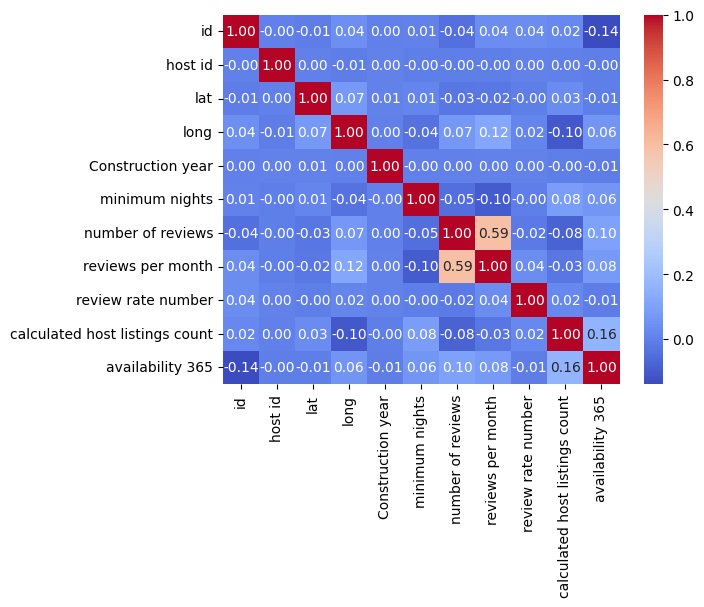

In [15]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

## 3. Categorical Relationships

In [24]:
# pd.crosstab(df['room type'], df['price'], normalize=False)
sorted(df["price"].dropna().unique(), key=str)

# # Define price bins (adjust as needed)
# bins = [0, 500, 1000, 5000]
# labels = ["0-500", "500-1000", "1000-5000"]

# # Create a new binned column
# df["price_bin"] = pd.cut(df["price"].dropna(), bins=bins, labels=labels, include_lowest=True)

# # Crosstab using the binned prices
# ct = pd.crosstab(df["room type"], df["price_bin"], normalize=True)

['$1,000 ',
 '$1,001 ',
 '$1,002 ',
 '$1,003 ',
 '$1,004 ',
 '$1,005 ',
 '$1,006 ',
 '$1,007 ',
 '$1,008 ',
 '$1,009 ',
 '$1,010 ',
 '$1,011 ',
 '$1,012 ',
 '$1,013 ',
 '$1,014 ',
 '$1,015 ',
 '$1,016 ',
 '$1,017 ',
 '$1,018 ',
 '$1,019 ',
 '$1,020 ',
 '$1,021 ',
 '$1,022 ',
 '$1,023 ',
 '$1,024 ',
 '$1,025 ',
 '$1,026 ',
 '$1,027 ',
 '$1,028 ',
 '$1,029 ',
 '$1,030 ',
 '$1,031 ',
 '$1,032 ',
 '$1,033 ',
 '$1,034 ',
 '$1,035 ',
 '$1,036 ',
 '$1,037 ',
 '$1,038 ',
 '$1,039 ',
 '$1,040 ',
 '$1,041 ',
 '$1,042 ',
 '$1,043 ',
 '$1,044 ',
 '$1,045 ',
 '$1,046 ',
 '$1,047 ',
 '$1,048 ',
 '$1,049 ',
 '$1,050 ',
 '$1,051 ',
 '$1,052 ',
 '$1,053 ',
 '$1,054 ',
 '$1,055 ',
 '$1,056 ',
 '$1,057 ',
 '$1,058 ',
 '$1,059 ',
 '$1,060 ',
 '$1,061 ',
 '$1,062 ',
 '$1,063 ',
 '$1,064 ',
 '$1,065 ',
 '$1,066 ',
 '$1,067 ',
 '$1,068 ',
 '$1,069 ',
 '$1,070 ',
 '$1,071 ',
 '$1,072 ',
 '$1,073 ',
 '$1,074 ',
 '$1,075 ',
 '$1,076 ',
 '$1,077 ',
 '$1,078 ',
 '$1,079 ',
 '$1,080 ',
 '$1,081 ',
 '$1,082 ',
 '$1